# PepLink Quick Start

Each example below is a separate runnable cell. If a cell generates a SMILES string, it also renders the corresponding molecule.


## Notebook Setup

Run this cell first. It adds the repo root to `sys.path`, imports the public APIs, and defines `show_smiles(...)` for molecule rendering.


In [34]:
from pathlib import Path
import sys

from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw


def find_repo_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "PepLink").is_dir() and (candidate / "all_peptides_data.json").exists():
            return candidate
    raise RuntimeError("Could not locate the PepLink repository root from the current working directory.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

for module_name in list(sys.modules):
    if module_name == "PepLink" or module_name.startswith("PepLink."):
        sys.modules.pop(module_name)

from PepLink import (
    aa_seqs_to_smiles,
    clear_registered_noncanonical_aas,
    from_dbaasp_record,
    list_supported_noncanonical_aas,
    load_noncanonical_aas_from_csv,
    register_noncanonical_aa,
    register_noncanonical_aas,
    register_noncanonical_aas_from_csv,
    smiles_to_aa_seqs,
)


def show_smiles(smiles: str, *, size: tuple[int, int] = (900, 300)):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES string")
    display(smiles)
    display(Draw.MolToImage(mol, size=size))
    return mol
        


## Basic `aa_seqs_to_smiles(...)` example


[20:25:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:18] Initializing MetalDisconnector
[20:25:18] Running MetalDisconnector
[20:25:18] Initializing Normalizer
[20:25:18] Running Normalizer
[20:25:18] Initializing MetalDisconnector
[20:25:18] Running MetalDisconnector
[20:25:18] Initializing Normalizer
[20:25:18] Running Normalizer
[20:25:18] Running LargestFragmentChooser
[20:25:18] Running Uncharger


'CC(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@](C)(C(=O)N[C@@](C)(C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](Cc1ccccc1)C(N)=O)c1cccc2ccccc12)c1cccc2ccccc12'

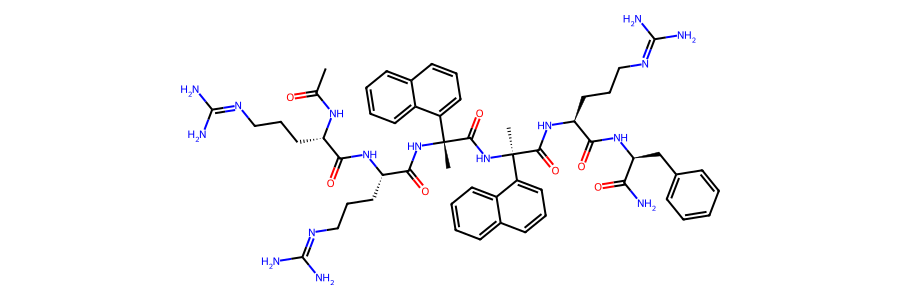

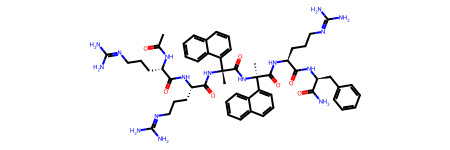

In [2]:
smiles = aa_seqs_to_smiles(
    "RRXXRF",
    unusual_amino_acids=[
        {"position": 3, "name": "1-NAL"},
        {"position": 4, "name": "1-NAL"},
    ],
    n_terminal="ACT",
    c_terminal="AMD",
)
show_smiles(smiles)
        


## Head-to-tail cyclic peptide round trip


[02:45:16] Initializing MetalDisconnector
[02:45:16] Running MetalDisconnector
[02:45:16] Initializing Normalizer
[02:45:16] Running Normalizer
[02:45:16] Initializing MetalDisconnector
[02:45:16] Running MetalDisconnector
[02:45:16] Initializing Normalizer
[02:45:16] Running Normalizer
[02:45:16] Running LargestFragmentChooser
[02:45:16] Running Uncharger


'C[C@@H](O)[C@@H]1NC(=O)[C@@H](CCCCN)NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@@H](Cc2c[nH]c3ccccc23)NC(=O)[C@H](CO)NC(=O)[C@@H](CCCCN)NC(=O)[C@H](CO)NC(=O)[C@@H](CCCCN)NC1=O'

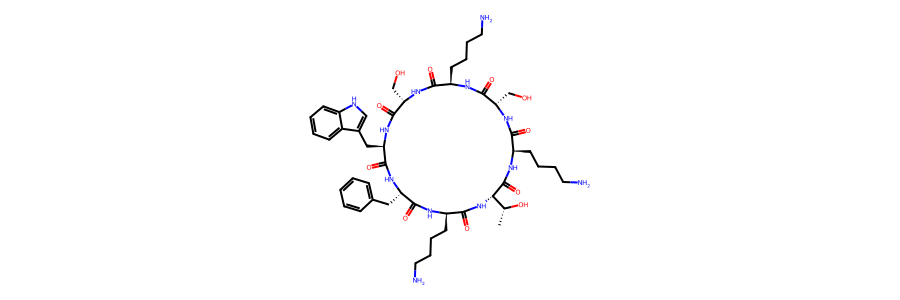

[02:45:16] Initializing MetalDisconnector
[02:45:16] Running MetalDisconnector
[02:45:16] Initializing Normalizer
[02:45:16] Running Normalizer
[02:45:16] Initializing MetalDisconnector
[02:45:16] Running MetalDisconnector
[02:45:16] Initializing Normalizer
[02:45:16] Running Normalizer
[02:45:16] Running LargestFragmentChooser
[02:45:16] Running Uncharger
[02:45:16] Initializing MetalDisconnector
[02:45:16] Running MetalDisconnector
[02:45:16] Initializing Normalizer
[02:45:16] Running Normalizer
[02:45:16] Initializing MetalDisconnector
[02:45:16] Running MetalDisconnector
[02:45:16] Initializing Normalizer
[02:45:16] Running Normalizer
[02:45:16] Running LargestFragmentChooser
[02:45:16] Running Uncharger


PeptideParseResult(sequence='FkTkSkSw', is_cyclic=True, cyclization='head_to_tail', normalized_smiles='C[C@@H](O)[C@@H]1NC(=O)[C@@H](CCCCN)NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@@H](Cc2c[nH]c3ccccc23)NC(=O)[C@H](CO)NC(=O)[C@@H](CCCCN)NC(=O)[C@H](CO)NC(=O)[C@@H](CCCCN)NC1=O', input_format='smiles', unsupported_reason=None)

In [35]:
head_to_tail_smiles = aa_seqs_to_smiles(
    "SwFkTkSk",
    intrachain_bonds=[
        {"position1": 1, "position2": 8, "type": "AMD", "chain_participating": "MMB"},
    ],
)
show_smiles(head_to_tail_smiles)
smiles_to_aa_seqs(head_to_tail_smiles)


## Linear peptide from dataset `id=11`


[20:25:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:41] Initializing MetalDisconnector
[20:25:41] Running MetalDisconnector
[20:25:41] Initializing Normalizer
[20:25:41] Running Normalizer
[20:25:41] Initializing MetalDisconnector
[20:25:41] Running MetalDisconnector
[20:25:41] Initializing Normalizer
[20:25:41] Running Normalizer
[20:25:41] Running LargestFragmentChooser
[20:25:41] Running Uncharger


'CC[C@H](C)[C@H](NC(=O)[C@H](C)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](Cc1ccc(O)cc1)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(N)=O)NC(=O)[C@H](Cc1ccc(O)cc1)NC(=O)CNC(=O)[C@H](C)NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H]1CCCN1C(=O)[C@H](Cc1c[nH]c2ccccc12)NC(=O)[C@@H](NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCCN)NC(=O)[C@@H](NC(=O)[C@@H](N)CCCN=C(N)N)C(C)C)C(C)C)C(C)C)[C@@H](C)CC)[C@@H](C)O)C(C)C)[C@@H](C)CC)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)O'

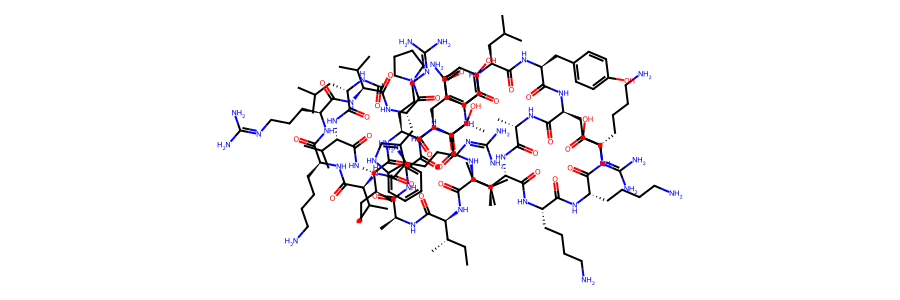

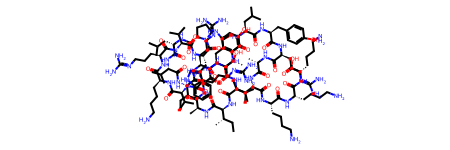

In [4]:
smiles = aa_seqs_to_smiles("RVKRVWPLVIRTVIAGYNLYRAIKKK")
show_smiles(smiles)
        


## Single non-canonical residue from dataset `id=151`


[20:25:46] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:46] Initializing MetalDisconnector
[20:25:46] Running MetalDisconnector
[20:25:46] Initializing Normalizer
[20:25:46] Running Normalizer
[20:25:46] Initializing MetalDisconnector
[20:25:46] Running MetalDisconnector
[20:25:46] Initializing Normalizer
[20:25:46] Running Normalizer
[20:25:46] Running LargestFragmentChooser
[20:25:46] Fragment: CC[C@H](C)[C@@H]1NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCCCN)NC1=O
[20:25:46] New largest fragment: CC[C@H](C)[C@@H]1NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCCCN)NC1=O (63)
[20:25:46] Fragment: CC[C@H](C)[C@H](NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCC(N)=O)NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCCN)NCCOc1ccccc1)[C@@H](C)CC)C(C)C)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](CC(N)=O)C(=O)N[C@@H](CC(C)C)C(=O)N[C@H](C(=O)O)C(C)C
[20:25:46] New largest fragment:

'CC[C@H](C)[C@H](NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCC(N)=O)NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCCN)NCCOc1ccccc1)[C@@H](C)CC)C(C)C)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](CC(N)=O)C(=O)N[C@@H](CC(C)C)C(=O)N[C@H](C(=O)O)C(C)C'

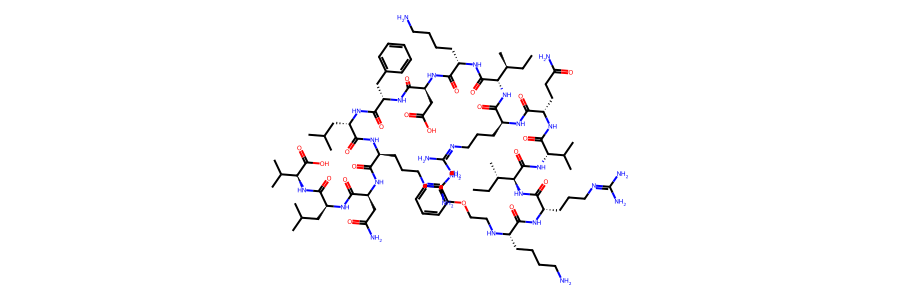

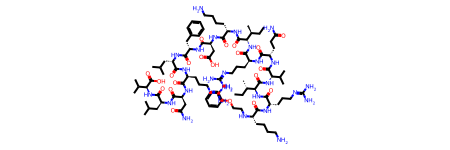

In [5]:
smiles = aa_seqs_to_smiles(
    "GIKEXKRIVQRIKDFLRNLV",
    unusual_amino_acids=[
        {"position": 5, "name": "Phg"},
    ],
)
show_smiles(smiles)
        


## Multiple non-canonical residues from dataset `id=157`


[20:25:50] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:50] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:50] Initializing MetalDisconnector
[20:25:50] Running MetalDisconnector
[20:25:50] Initializing Normalizer
[20:25:50] Running Normalizer
[20:25:50] Initializing MetalDisconnector
[20:25:50] Running MetalDisconnector
[20:25:50] Initializing Normalizer
[20:25:50] Running Normalizer
[20:25:50] Running LargestFragmentChooser
[20:25:50] Fragment: NCCCC[C@@H]1NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@H](CCCN=C(N)N)NC(=O)CNC(=O)[C@H](CCCN=C(N)N)NC1=O
[20:25:50] New largest fragment: NCCCC[C@@H]1NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@H](CCCN=C(N)N)NC(=O)CNC(=O)[C@H](CCCN=C(N)N)NC1=O (94)
[20:25:50] Fragment: CC[C@H](C)[C@H](NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCCN=C(N)N)NCCOc1ccccc1)C(=O)N[C@@H](CO)C(=O)O
[2

'CC[C@H](C)[C@H](NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCCN=C(N)N)NCCOc1ccccc1)C(=O)N[C@@H](CO)C(=O)O'

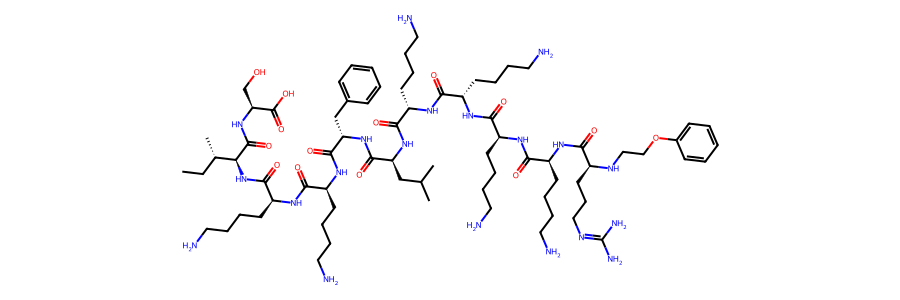

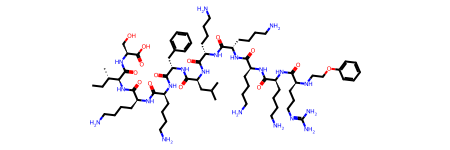

In [6]:
smiles = aa_seqs_to_smiles(
    "GRFKRXRKKXKKLFKKIS",
    unusual_amino_acids=[
        {"position": 6, "name": "Phg"},
        {"position": 10, "name": "Phg"},
    ],
)
show_smiles(smiles)
        


## Terminal modifications from dataset `id=10360`


[20:25:53] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:53] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:53] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:53] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:53] Initializing MetalDisconnector
[20:25:53] Running MetalDisconnector
[20:25:53] Initializing Normalizer
[20:25:53] Running Normalizer
[20:25:53] Initializing MetalDisconnector
[20:25:53] Running MetalDisconnector
[20:25:53] Initializing Normalizer
[20:25:53] Running Normalizer
[20:25:53] Running LargestFragmentChooser
[20:25:53] Running Uncharger


'CCCCCCCCCCCCCCCC(=O)N[C@@H](CCCCN)C(N)=O'

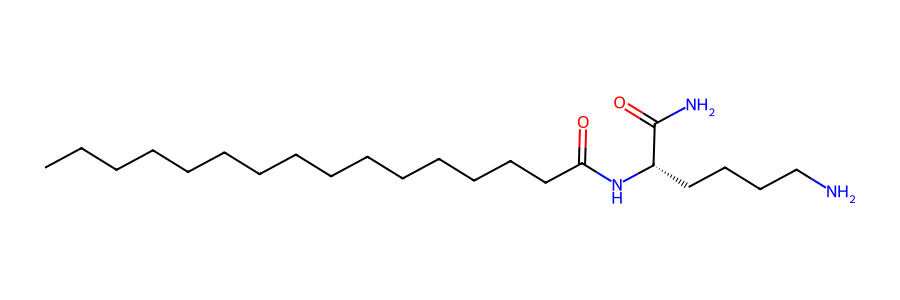

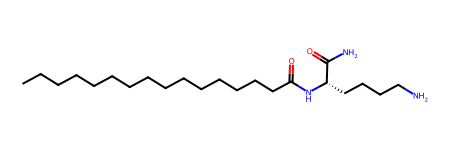

In [7]:
smiles = aa_seqs_to_smiles(
    "K",
    n_terminal="C16",
    c_terminal="AMD",
)
show_smiles(smiles)
        


## Terminal modifications with D-amino acids from dataset `id=8`


[20:25:55] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:55] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:55] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:55] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:25:55] Initializing MetalDisconnector
[20:25:55] Running MetalDisconnector
[20:25:55] Initializing Normalizer
[20:25:55] Running Normalizer
[20:25:55] Initializing MetalDisconnector
[20:25:55] Running MetalDisconnector
[20:25:55] Initializing Normalizer
[20:25:55] Running Normalizer
[20:25:55] Running LargestFragmentChooser
[20:25:55] Running Uncharger


'CCCCCCCCCCCCCCCC(=O)N[C@@H](CCCCN)C(=O)N[C@H](C(=O)N[C@@H](C(=O)N[C@@H](C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@H](C(=O)N[C@@H](C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](C(=O)N[C@H](C(=O)N[C@@H](CCCCN)C(N)=O)C(C)C)C(C)C)C(C)C)C(C)C)C(C)C)C(C)C)C(C)C'

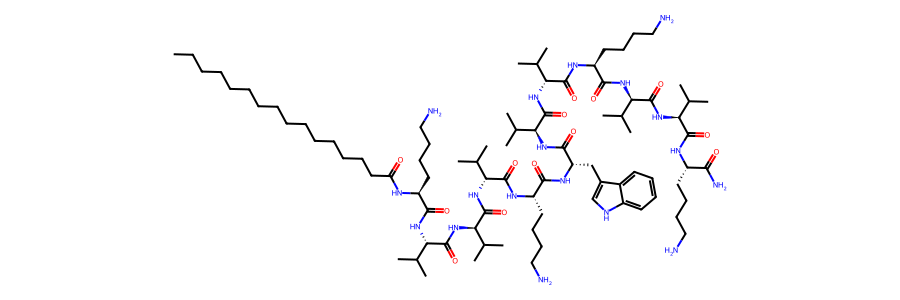

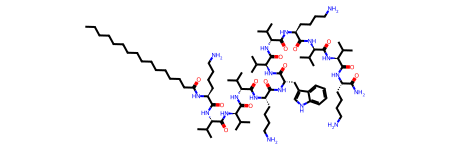

In [8]:
smiles = aa_seqs_to_smiles(
    "KVvvKWVvKvVK",
    n_terminal="C16",
    c_terminal="AMD",
)
show_smiles(smiles)
        


## `DSB` intrachain bonds from dataset `id=57`


[20:25:58] Initializing MetalDisconnector
[20:25:58] Running MetalDisconnector
[20:25:58] Initializing Normalizer
[20:25:58] Running Normalizer
[20:25:58] Initializing MetalDisconnector
[20:25:58] Running MetalDisconnector
[20:25:58] Initializing Normalizer
[20:25:58] Running Normalizer
[20:25:58] Running LargestFragmentChooser
[20:25:58] Running Uncharger


'CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(=O)O)NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@@H](N)C(C)C)[C@@H](C)O)CSSC[C@@H]2NC(=O)[C@H](Cc3ccc(O)cc3)NC(=O)CNC(=O)CNC(=O)[C@H](CO)NC(=O)[C@H](CCCN=C(N)N)NC(=O)CNC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](Cc3ccccc3)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H]3CSSC[C@@H](C(=O)N[C@@H](CCCN=C(N)N)C(=O)O)NC(=O)[C@H](C(C)C)NC(=O)[C@H](CSSC[C@H](NC(=O)[C@H](C)NC(=O)[C@H](C)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CC(N)=O)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCCCN)NC(=O)[C@H](C(C)C)NC(=O)CNC(=O)[C@H](CCCCN)NC(=O)[C@H](C)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](C(C)C)NC(=O)[C@H](CO)NC(=O)[C@H](CC(C)C)NC1=O)C(=O)N[C@@H](C)C(=O)N[C@@H](C)C(=O)N[C@@H](Cc1cnc[nH]1)C(=O)N3)NC(=O)[C@H](C(C)C)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCCN)NC(=O)CNC(=O)[C@H](CC(N)=O)NC2=O'

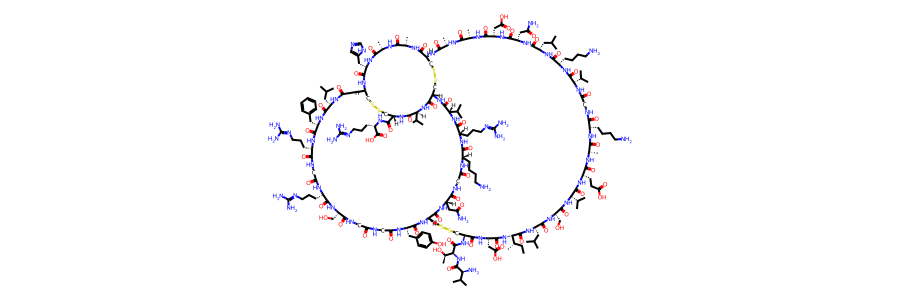

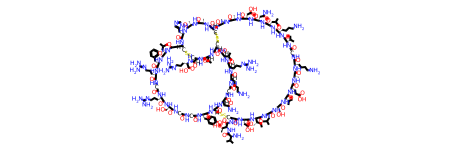

In [9]:
smiles = aa_seqs_to_smiles(
    "VTCDILSVEAKGVKLNDAACAAHCLFRGRSGGYCNGKRVCVCR",
    intrachain_bonds=[
        {"position1": 3, "position2": 34, "type": "DSB", "chain_participating": "SSB"},
        {"position1": 20, "position2": 40, "type": "DSB", "chain_participating": "SSB"},
        {"position1": 24, "position2": 42, "type": "DSB", "chain_participating": "SSB"},
    ],
)
show_smiles(smiles)
        


## `AMD` head-to-tail cyclization from dataset `id=105`


[20:26:02] Initializing MetalDisconnector
[20:26:02] Running MetalDisconnector
[20:26:02] Initializing Normalizer
[20:26:02] Running Normalizer
[20:26:02] Initializing MetalDisconnector
[20:26:02] Running MetalDisconnector
[20:26:02] Initializing Normalizer
[20:26:02] Running Normalizer
[20:26:02] Running LargestFragmentChooser
[20:26:02] Running Uncharger


'C[C@@H](O)[C@@H]1NC(=O)[C@@H](CCCCN)NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@@H](Cc2c[nH]c3ccccc23)NC(=O)[C@H](CO)NC(=O)[C@@H](CCCCN)NC(=O)[C@H](CO)NC(=O)[C@@H](CCCCN)NC1=O'

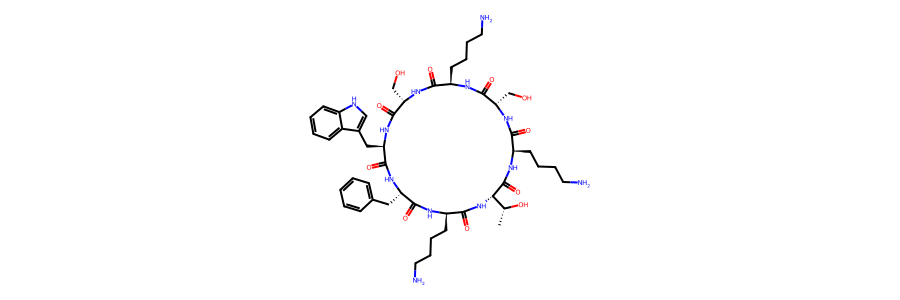

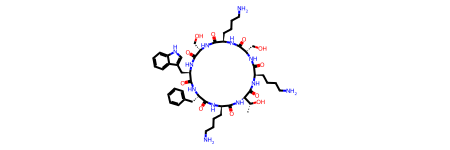

In [10]:
smiles = aa_seqs_to_smiles(
    "SwFkTkSk",
    intrachain_bonds=[
        {"position1": 1, "position2": 8, "type": "AMD", "chain_participating": "MMB"},
    ],
)
show_smiles(smiles)
        


## `TIE` bonds from dataset `id=1079`


[20:26:04] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:04] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:04] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:04] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:04] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:04] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:04] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:04] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:04] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:04] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:04] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:04] DEPRECATIO

'CC=C1NC(=O)[C@H]([C@@H](C)CC)NC(=O)[C@H]([C@@H](C)CC)NC(=O)[C@H](CSC[C@H](NC(=O)[C@H](CC(C)C)N[C@@H]2CC(O)(C(=O)O)O[C@H](C(=O)O)[C@@H]2O)C(=O)N[C@@H]2C(=O)N3CCC[C@H]3C(=O)NCC(=O)N[C@H](C(=O)N[C@@H](CCCCN)C(=O)N[C@@H]3C(=O)NCC(=O)N[C@@H](C)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCSC)C(=O)NCC(=O)N[C@H](C(=O)N[C@@H](CC(N)=O)C(=O)N[C@@H](CCSC)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H]4C(=O)N[C@@H](C)C(=O)N[C@@H]5C(=O)N[C@@H](CS[C@@H]4C)C(=O)N[C@@H](Cc4cnc[nH]4)C(=O)N[C@H](C(=O)N[C@@H](CO)C(=O)N[C@H](C(=O)N[C@@H](Cc4cnc[nH]4)C(=O)N[C@H](C(=O)N[C@@H](CCCCN)C(=O)O)C(C)C)[C@@H](C)CC)CS[C@@H]5C)CS[C@@H]3C)CS[C@@H]2C)NC1=O'

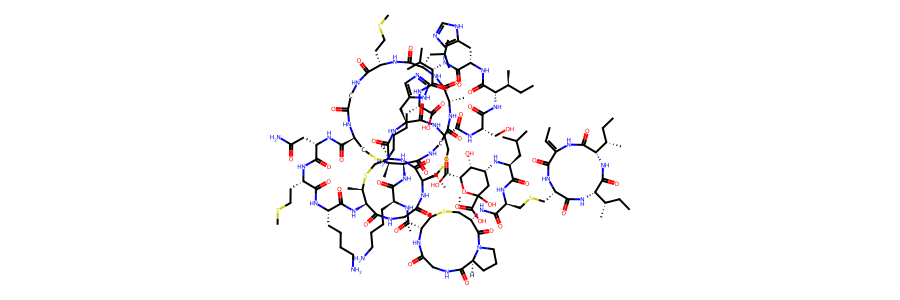

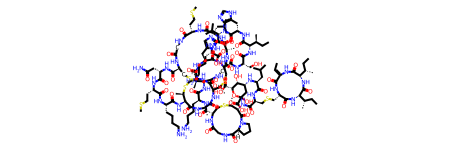

In [11]:
smiles = aa_seqs_to_smiles(
    "IXSIXLCTPGCKTGALMGCNMKTATCHCSIHVXK",
    unusual_amino_acids=[
        {"position": 2, "name": "DHB"},
        {"position": 5, "name": "DHA"},
        {"position": 33, "name": "DHA"},
    ],
    intrachain_bonds=[
        {"position1": 3, "position2": 7, "type": "TIE", "chain_participating": "SSB"},
        {"position1": 8, "position2": 11, "type": "TIE", "chain_participating": "SSB"},
        {"position1": 13, "position2": 19, "type": "TIE", "chain_participating": "SSB"},
        {"position1": 23, "position2": 26, "type": "TIE", "chain_participating": "SSB"},
        {"position1": 25, "position2": 28, "type": "TIE", "chain_participating": "SSB"},
    ],
)
show_smiles(smiles)
        


## `DCB` bonds from dataset `id=4419`


[20:26:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:07] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:07] DEPRECATIO

'CC[C@H](C)[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H](CC(C)C)NC(=O)[C@@H](N)Cc1ccccc1)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](C)C(=O)N[C@@H](CO)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](C)C(=O)N[C@@H](C)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](Cc1ccccc1)C(=O)NCC(=O)N1CCC[C@H]1C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@H]1CC=CC[C@@H](C(=O)O)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCCCN)NC(=O)[C@H]([C@@H](C)O)NC(=O)[C@H](C(C)C)NC(=O)[C@H](CC(C)C)NC1=O'

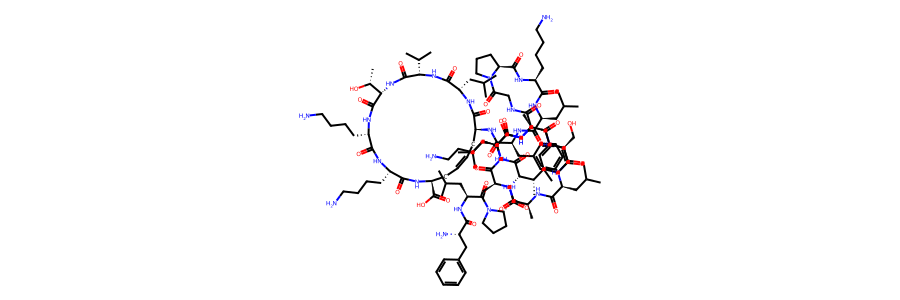

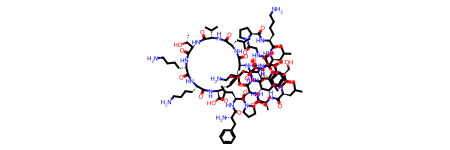

In [12]:
smiles = aa_seqs_to_smiles(
    "FLPILASLAAKFGPKLFXLVTKKX",
    unusual_amino_acids=[
        {"position": 18, "name": "AGL"},
        {"position": 24, "name": "AGL"},
    ],
    intrachain_bonds=[
        {"position1": 18, "position2": 24, "type": "DCB", "chain_participating": "SSB"},
    ],
)
show_smiles(smiles)
        


## `EST` bonds from dataset `id=6917`


[20:26:10] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:10] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:10] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:10] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:10] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:10] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:10] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:10] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:10] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:10] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:10] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:10] DEPRECATIO

'CCCCCCCCCCCCC(C)(O)C(O)CC(=O)N[C@H]1COC(=O)[C@@H]([C@@H](C)O)NC(=O)[C@@H](CO)NC(=O)[C@@H](CO)NC(=O)[C@H](C)NC(=O)[C@@H](CC(=O)O)NC(=O)[C@@H](C)NC1=O'

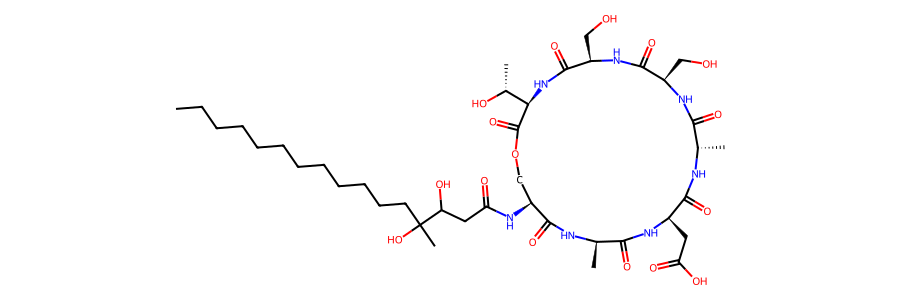

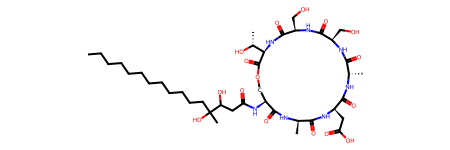

In [13]:
smiles = aa_seqs_to_smiles(
    "SadAssX",
    unusual_amino_acids=[
        {"position": 7, "name": "D-Allo-Thr"},
    ],
    n_terminal="3,4-OH-4-Me-C16",
    intrachain_bonds=[
        {"position1": 0, "position2": 7, "type": "EST", "chain_participating": "MMB"},
    ],
)
show_smiles(smiles)
        


## `AMN` bonds from dataset `id=19104`


[20:26:12] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:12] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:12] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:12] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:12] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:12] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:12] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:12] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:12] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:12] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:12] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:12] DEPRECATIO

'CC(C)C[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)CNC(=O)[C@H](Cc2ccc(O)cc2)N[C@@H]2CC(C(=O)O)(NCCCC[C@@H](C(=O)O)NC(=O)[C@H]3NC(=O)[C@H](CC(N)=O)NC(=O)CNC(=O)C(C(O)C(=O)O)NC(=O)[C@@H]4CSC[C@@H]5NC(=O)[C@H](CC(N)=O)NC(=O)[C@H](C)NC(=O)[C@H](CS[C@@H]3C)NC(=O)[C@H](CS[C@H](C)[C@H](NC1=O)C(=O)N[C@@H](Cc1c[nH]c3ccccc13)C(=O)N[C@@H](CO)C(=O)N4)NC5=O)O[C@H](C(=O)O)[C@@H]2O'

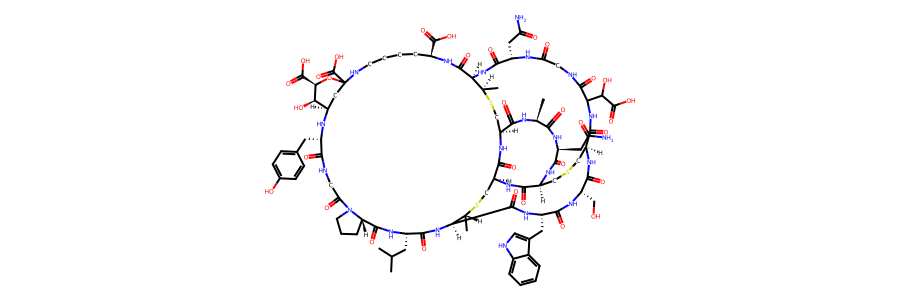

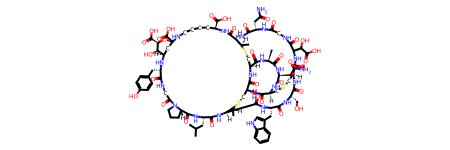

In [14]:
smiles = aa_seqs_to_smiles(
    "CANSCXYGPLTWSCXGNTK",
    unusual_amino_acids=[
        {"position": 6, "name": "DHA"},
        {"position": 15, "name": "3-OH-Asp"},
    ],
    intrachain_bonds=[
        {"position1": 1, "position2": 18, "type": "TIE", "chain_participating": "SSB"},
        {"position1": 5, "position2": 11, "type": "TIE", "chain_participating": "SSB"},
        {"position1": 4, "position2": 14, "type": "TIE", "chain_participating": "SSB"},
        {"position1": 6, "position2": 19, "type": "AMN", "chain_participating": "SSB"},
    ],
)
show_smiles(smiles)
        


## `p-XylB` bonds from dataset `id=11913`


[20:26:14] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:14] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:14] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:14] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:14] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:14] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:14] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:14] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:14] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:14] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:14] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:14] Initializi

'NCCCC[C@@H]1NC(=O)[C@@H](CCCCN)NC(=O)[C@H](Cc2c[nH]c3ccccc23)NC(=O)[C@H](N)CSCc2ccc(cc2)CSC[C@@H](C(N)=O)NC(=O)[C@@H](CCCCN)NC1=O'

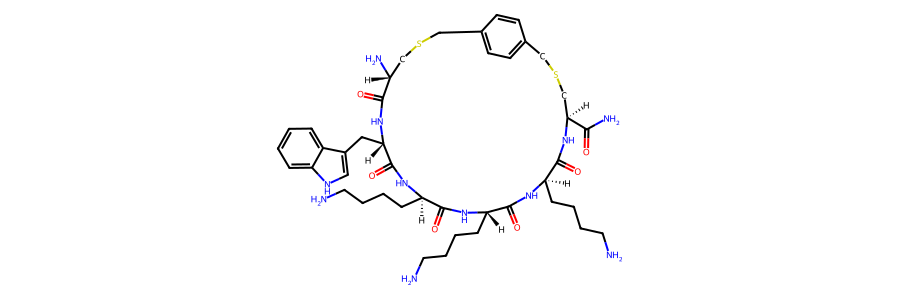

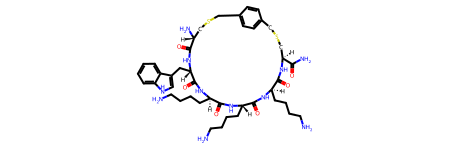

In [15]:
smiles = aa_seqs_to_smiles(
    "cWkKkC",
    c_terminal="AMD",
    intrachain_bonds=[
        {"position1": 1, "position2": 6, "type": "p-XylB", "chain_participating": "SSB"},
    ],
)
show_smiles(smiles)
        


## `TRZB` bonds from dataset `id=14660`


[20:26:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:17] Initializi

'CC[C@H](C)[C@@H]1NC(=O)[C@H](CO)NC(=O)[C@@H]2CCCN2C(=O)[C@H](C)NC(=O)CNC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCSC)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](Cc2c[nH]c3ccccc23)NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H](Cc2c[nH]c3ccccc23)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCN=C(N)N)NC(=O)C(NC(=O)[C@H](CCCCN)NC(=O)[C@@H](N)Cc2ccccc2)CCc2cn(nn2)CCCC[C@@H](C(=O)N[C@H](C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](C)C(=O)N[C@@H](Cc2ccccc2)C(=O)O)C(C)C)NC(=O)[C@H]([C@@H](C)O)NC1=O'

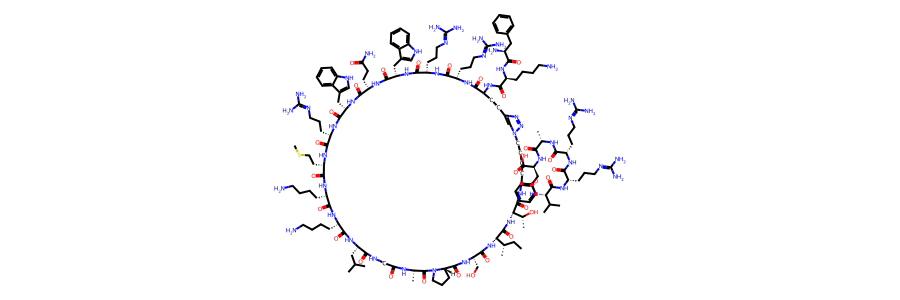

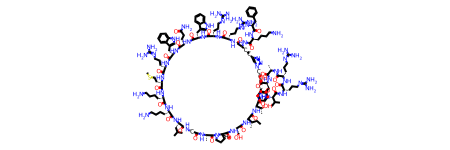

In [16]:
smiles = aa_seqs_to_smiles(
    "FKXRRWQWRMKKLGAPSITXVRRAF",
    unusual_amino_acids=[
        {"position": 3, "name": "BisHomo-Pra"},
        {"position": 20, "name": "Lys(N3)"},
    ],
    intrachain_bonds=[
        {"position1": 3, "position2": 20, "type": "TRZB", "chain_participating": "SSB"},
    ],
)
show_smiles(smiles)
        


## `(E)-but-2-enyl-B` bonds from dataset `id=17263`


[20:26:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:19] Initializing MetalDisconnector
[20:26:19] Running MetalDisconnector
[20:26:19] Initializing Normalizer
[20:26:19] Running Normalizer
[20:26:19] Initializing MetalDisconnector
[20:26:19] Running MetalDisconnector
[20:26:19] Initializing Normalizer
[20:26:19] Running Normalizer
[20:26:19] Running LargestFragmentChooser
[20:26:19] Running Uncharger


'CC(C)C[C@@H]1NC(=O)[C@H](CCCCN)NC(=O)[C@@H](NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@@H](N)CCCCN)CCCCNCC=CCNCCCC[C@@H](C(=O)N[C@@H](C)C(=O)N[C@H](C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)NCC(=O)N[C@@H](Cc2ccccc2)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](Cc2ccccc2)C(=O)N[C@@H](C)C(=O)N[C@@H](CCCCN)C(=O)N[C@H](C(=O)O)C(C)C)C(C)C)NC(=O)[C@H](CCCCN)NC1=O'

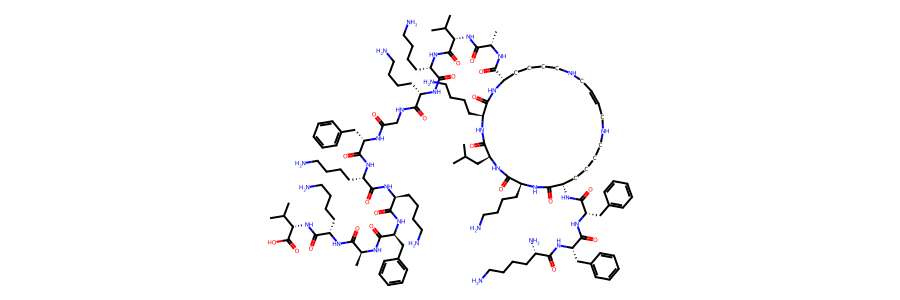

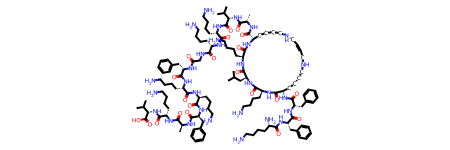

In [17]:
smiles = aa_seqs_to_smiles(
    "KFFKKLKKAVKKGFKKFAKV",
    intrachain_bonds=[
        {"position1": 4, "position2": 8, "type": "(E)-but-2-enyl-B", "chain_participating": "SSB"},
    ],
)
show_smiles(smiles)
        


## `BisMeBn-B` bonds from dataset `id=17273`


[20:26:21] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:21] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:21] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:21] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:21] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:21] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:21] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:21] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:21] Initializing MetalDisconnector
[20:26:21] Running MetalDisconnector
[20:26:21] Initializing Normalizer
[20:26:21] Running Normalizer
[20:26:21] Initializing MetalDisconnector
[20:26:21] Running MetalDisconnector
[20:26:21] Initializing Normalizer
[20:26:21] Running Normalizer


'CC(C)C[C@H](NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@@H](N)CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](C)C(=O)N[C@H](C(=O)N[C@@H](CCCCN)C(=O)N[C@H]1CCCCNCc2ccc(cc2)CNCCCC[C@@H](C(=O)N[C@@H](Cc2ccccc2)C(=O)N[C@@H](C)C(=O)N[C@@H](CCCCN)C(=O)N[C@H](C(=O)O)C(C)C)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc2ccccc2)NC(=O)CNC1=O)C(C)C'

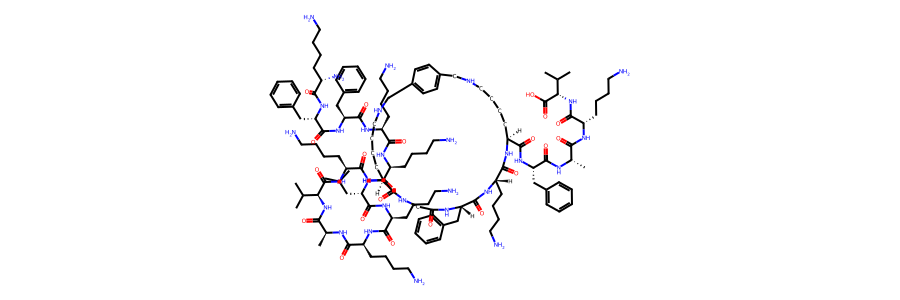

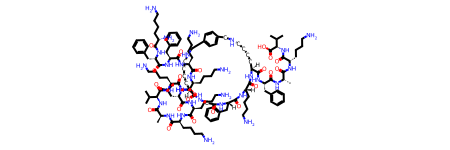

In [18]:
smiles = aa_seqs_to_smiles(
    "KFFKKLKKAVKKGFKKFAKV",
    intrachain_bonds=[
        {"position1": 12, "position2": 16, "type": "BisMeBn-B", "chain_participating": "SSB"},
    ],
)
show_smiles(smiles)
        


## `but-2-ynyl-B` bonds from dataset `id=19191`


[20:26:24] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:24] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:24] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:24] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:24] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:24] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:24] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:26:24] Initializing MetalDisconnector
[20:26:24] Running MetalDisconnector
[20:26:24] Initializing Normalizer
[20:26:24] Running Normalizer
[20:26:24] Initializing MetalDisconnector
[20:26:24] Running MetalDisconnector
[20:26:24] Initializing Normalizer
[20:26:24] Running Normalizer
[20:26:24] Running LargestFragmentChooser
[20:26:24] Running Uncharger


'CC(C)[C@H](N)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCCCN)C(=O)N[C@H]1CCCCNCC#CCNCCCC[C@@H](C(=O)N[C@@H](Cc2ccccc2)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](Cc2ccccc2)C(=O)N[C@H](C(N)=O)C(C)C)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@H](Cc2ccccc2)NC1=O'

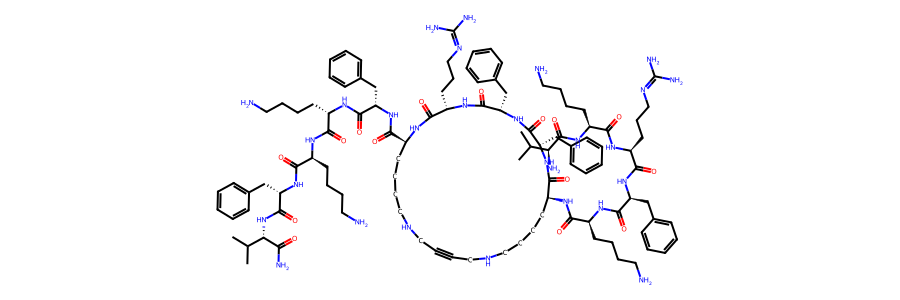

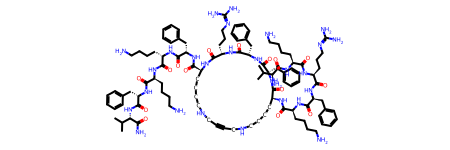

In [19]:
smiles = aa_seqs_to_smiles(
    "VKRFKKFFRKFKKFV",
    c_terminal="AMD",
    intrachain_bonds=[
        {"position1": 6, "position2": 10, "type": "but-2-ynyl-B", "chain_participating": "SSB"},
    ],
)
show_smiles(smiles)
        


## Reverse parsing of a linear peptide


[20:26:26] Initializing MetalDisconnector
[20:26:26] Running MetalDisconnector
[20:26:26] Initializing Normalizer
[20:26:26] Running Normalizer
[20:26:26] Initializing MetalDisconnector
[20:26:26] Running MetalDisconnector
[20:26:26] Initializing Normalizer
[20:26:26] Running Normalizer
[20:26:26] Running LargestFragmentChooser
[20:26:26] Running Uncharger


'C[C@H](N)C(=O)N[C@@H](CS)C(=O)O'

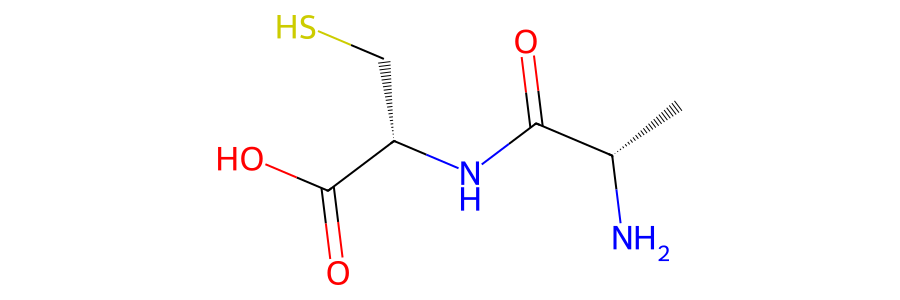

[20:26:26] Initializing MetalDisconnector
[20:26:26] Running MetalDisconnector
[20:26:26] Initializing Normalizer
[20:26:26] Running Normalizer
[20:26:26] Initializing MetalDisconnector
[20:26:26] Running MetalDisconnector
[20:26:26] Initializing Normalizer
[20:26:26] Running Normalizer
[20:26:26] Running LargestFragmentChooser
[20:26:26] Running Uncharger
[20:26:26] Initializing MetalDisconnector
[20:26:26] Running MetalDisconnector
[20:26:26] Initializing Normalizer
[20:26:26] Running Normalizer
[20:26:26] Initializing MetalDisconnector
[20:26:26] Running MetalDisconnector
[20:26:26] Initializing Normalizer
[20:26:26] Running Normalizer
[20:26:26] Running LargestFragmentChooser
[20:26:26] Running Uncharger


PeptideParseResult(sequence='AC', is_cyclic=False, cyclization='linear', normalized_smiles='C[C@H](N)C(=O)N[C@@H](CS)C(=O)O', input_format='smiles', unsupported_reason=None)

In [20]:
linear_smiles = aa_seqs_to_smiles("AC")
show_smiles(linear_smiles)
smiles_to_aa_seqs(linear_smiles)
        


## DBAASP-style helper example


[20:26:36] Initializing MetalDisconnector
[20:26:36] Running MetalDisconnector
[20:26:36] Initializing Normalizer
[20:26:36] Running Normalizer
[20:26:36] Initializing MetalDisconnector
[20:26:36] Running MetalDisconnector
[20:26:36] Initializing Normalizer
[20:26:36] Running Normalizer
[20:26:36] Running LargestFragmentChooser
[20:26:36] Running Uncharger


'CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(=O)O)NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@@H](N)C(C)C)[C@@H](C)O)CSSC[C@@H]2NC(=O)[C@H](Cc3ccc(O)cc3)NC(=O)CNC(=O)CNC(=O)[C@H](CO)NC(=O)[C@H](CCCN=C(N)N)NC(=O)CNC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](Cc3ccccc3)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H]3CSSC[C@@H](C(=O)N[C@@H](CCCN=C(N)N)C(=O)O)NC(=O)[C@H](C(C)C)NC(=O)[C@H](CSSC[C@H](NC(=O)[C@H](C)NC(=O)[C@H](C)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CC(N)=O)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCCCN)NC(=O)[C@H](C(C)C)NC(=O)CNC(=O)[C@H](CCCCN)NC(=O)[C@H](C)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](C(C)C)NC(=O)[C@H](CO)NC(=O)[C@H](CC(C)C)NC1=O)C(=O)N[C@@H](C)C(=O)N[C@@H](C)C(=O)N[C@@H](Cc1cnc[nH]1)C(=O)N3)NC(=O)[C@H](C(C)C)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCCN)NC(=O)CNC(=O)[C@H](CC(N)=O)NC2=O'

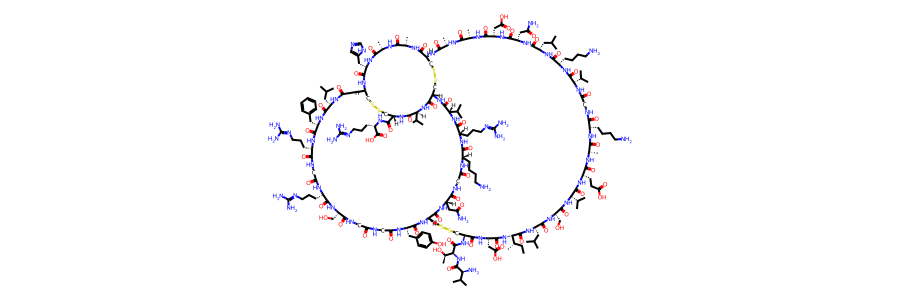

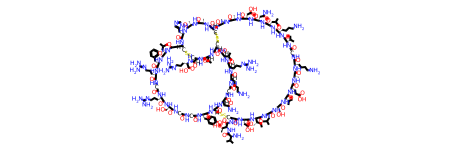

In [22]:
import json

records = json.loads((REPO_ROOT / "all_peptides_data.json").read_text())
record = next(item for item in records if item["id"] == 57)

inputs = from_dbaasp_record(record)
smiles = aa_seqs_to_smiles(**inputs.to_api_kwargs())
show_smiles(smiles)
        


## Runtime non-canonical amino-acid registry


## Inspect bundled non-canonical amino-acid mappings


In [29]:
supported = list_supported_noncanonical_aas()
print(f"total supported non-canonical residues: {len(supported)}")
print("1-NAL ->", supported["1-NAL"])
print("first 10 names:", list(supported)[:10])


total supported non-canonical residues: 420
1-NAL -> C[C@@](C1=CC=CC2=CC=CC=C21)(C(=O)O)N
first 10 names: ['(CH3)3-Gly', '1-NAL', '10-Adc', '11-NH2-C11', '12-Guan-C12', '12-NH2-C12', '13-N,N-Me-Guan-(E)2,4,8-C13', '2,5,7 TERT BU TRP ', '2-Abz', '2-Adc']


## Register one custom non-canonical amino acid


registered MyAA as CC[C@H](N)C(=O)O


[21:53:08] Initializing MetalDisconnector
[21:53:08] Running MetalDisconnector
[21:53:08] Initializing Normalizer
[21:53:08] Running Normalizer
[21:53:08] Initializing MetalDisconnector
[21:53:08] Running MetalDisconnector
[21:53:08] Initializing Normalizer
[21:53:08] Running Normalizer
[21:53:08] Running LargestFragmentChooser
[21:53:08] Running Uncharger
[21:53:08] Initializing MetalDisconnector
[21:53:08] Running MetalDisconnector
[21:53:08] Initializing Normalizer
[21:53:08] Running Normalizer
[21:53:08] Initializing MetalDisconnector
[21:53:08] Running MetalDisconnector
[21:53:08] Initializing Normalizer
[21:53:08] Running Normalizer
[21:53:08] Running LargestFragmentChooser
[21:53:08] Running Uncharger


'CC[C@H](NC(=O)[C@H](C)N)C(=O)N[C@@H](C)C(=O)O'

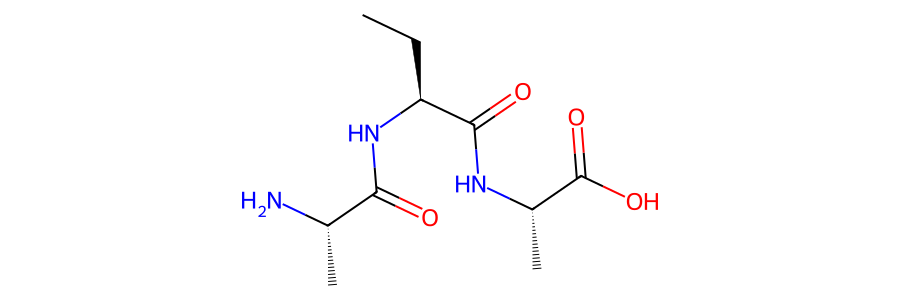

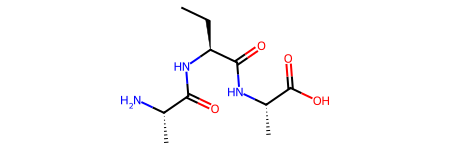

In [30]:
clear_registered_noncanonical_aas()

normalized_smiles = register_noncanonical_aa("MyAA", "N[C@@H](CC)C(=O)O")
print("registered MyAA as", normalized_smiles)

smiles = aa_seqs_to_smiles(
    "AXA",
    unusual_amino_acids=[{"position": 2, "name": "MyAA"}],
)
show_smiles(smiles)


## Register multiple custom non-canonical amino acids


In [31]:
clear_registered_noncanonical_aas()

registered = register_noncanonical_aas(
    {
        "MyAA": "N[C@@H](CC)C(=O)O",
        "MyAA2": "N[C@@H](CO)C(=O)O",
    }
)
print(registered)
print("contains MyAA2:", "MyAA2" in list_supported_noncanonical_aas())

clear_registered_noncanonical_aas()
print("contains MyAA after clear:", "MyAA" in list_supported_noncanonical_aas())


{'MyAA': 'CC[C@H](N)C(=O)O', 'MyAA2': 'N[C@@H](CO)C(=O)O'}
contains MyAA2: True
contains MyAA after clear: False


[21:53:20] Initializing MetalDisconnector
[21:53:20] Running MetalDisconnector
[21:53:20] Initializing Normalizer
[21:53:20] Running Normalizer
[21:53:20] Initializing MetalDisconnector
[21:53:20] Running MetalDisconnector
[21:53:20] Initializing Normalizer
[21:53:20] Running Normalizer
[21:53:20] Running LargestFragmentChooser
[21:53:20] Running Uncharger
[21:53:20] Initializing MetalDisconnector
[21:53:20] Running MetalDisconnector
[21:53:20] Initializing Normalizer
[21:53:20] Running Normalizer
[21:53:20] Initializing MetalDisconnector
[21:53:20] Running MetalDisconnector
[21:53:20] Initializing Normalizer
[21:53:20] Running Normalizer
[21:53:20] Running LargestFragmentChooser
[21:53:20] Running Uncharger


## Register custom non-canonical amino acids from a CSV file


/Users/kirianozan/Documents/工作/Published_packages/PepLink/examples/example_custom_noncanonical_aas.csv
{'MyAA': 'CC[C@H](N)C(=O)O', 'MyAA2': 'N[C@@H](CO)C(=O)O'}
{'MyAA': 'CC[C@H](N)C(=O)O', 'MyAA2': 'N[C@@H](CO)C(=O)O'}


[23:05:18] Initializing MetalDisconnector
[23:05:18] Running MetalDisconnector
[23:05:18] Initializing Normalizer
[23:05:18] Running Normalizer
[23:05:19] Initializing MetalDisconnector
[23:05:19] Running MetalDisconnector
[23:05:19] Initializing Normalizer
[23:05:19] Running Normalizer
[23:05:19] Running LargestFragmentChooser
[23:05:19] Running Uncharger
[23:05:19] Initializing MetalDisconnector
[23:05:19] Running MetalDisconnector
[23:05:19] Initializing Normalizer
[23:05:19] Running Normalizer
[23:05:19] Initializing MetalDisconnector
[23:05:19] Running MetalDisconnector
[23:05:19] Initializing Normalizer
[23:05:19] Running Normalizer
[23:05:19] Running LargestFragmentChooser
[23:05:19] Running Uncharger
[23:05:19] Initializing MetalDisconnector
[23:05:19] Running MetalDisconnector
[23:05:19] Initializing Normalizer
[23:05:19] Running Normalizer
[23:05:19] Initializing MetalDisconnector
[23:05:19] Running MetalDisconnector
[23:05:19] Initializing Normalizer
[23:05:19] Running Norma

'CC[C@H](NC(=O)[C@H](C)N)C(=O)N[C@@H](C)C(=O)O'

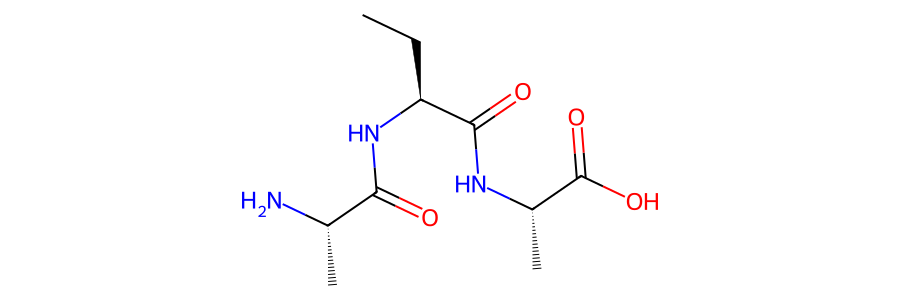

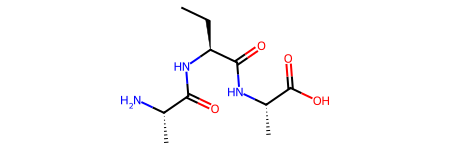

In [33]:
clear_registered_noncanonical_aas()

csv_path = REPO_ROOT / "examples" / "example_custom_noncanonical_aas.csv"
print(csv_path)
print(load_noncanonical_aas_from_csv(csv_path))

registered = register_noncanonical_aas_from_csv(csv_path)
print(registered)

smiles = aa_seqs_to_smiles(
    "AXA",
    unusual_amino_acids=[{"position": 2, "name": "MyAA"}],
)
show_smiles(smiles)


## Add a missing unusual amino acid with `aa_overrides`


[20:40:48] Initializing MetalDisconnector
[20:40:48] Running MetalDisconnector
[20:40:48] Initializing Normalizer
[20:40:48] Running Normalizer
[20:40:48] Initializing MetalDisconnector
[20:40:48] Running MetalDisconnector
[20:40:48] Initializing Normalizer
[20:40:48] Running Normalizer
[20:40:48] Running LargestFragmentChooser
[20:40:48] Running Uncharger


'CC[C@H](NC(=O)[C@H](C)N)C(=O)N[C@@H](C)C(=O)O'

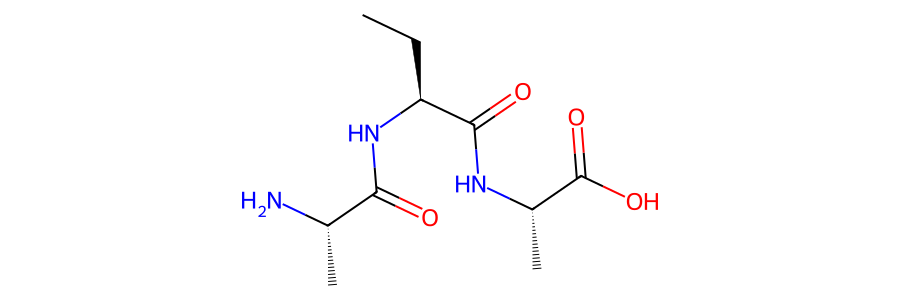

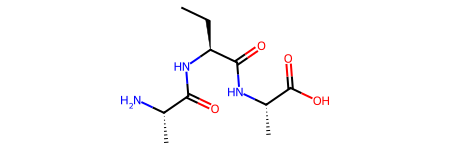

In [23]:
smiles = aa_seqs_to_smiles(
    "AXA",
    unusual_amino_acids=[{"position": 2, "name": "MyAA"}],
    aa_overrides={"MyAA": "N[C@@H](CC)C(=O)O"},
)
show_smiles(smiles)
        


## Add terminal modifications with override mappings


[20:40:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:40:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:40:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:40:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[20:40:51] Initializing MetalDisconnector
[20:40:51] Running MetalDisconnector
[20:40:51] Initializing Normalizer
[20:40:51] Running Normalizer
[20:40:51] Initializing MetalDisconnector
[20:40:51] Running MetalDisconnector
[20:40:51] Initializing Normalizer
[20:40:51] Running Normalizer
[20:40:51] Running LargestFragmentChooser
[20:40:51] Running Uncharger


'CC(=O)N[C@@H](C)C(=O)N[C@@H](CCCCN)C(N)=O'

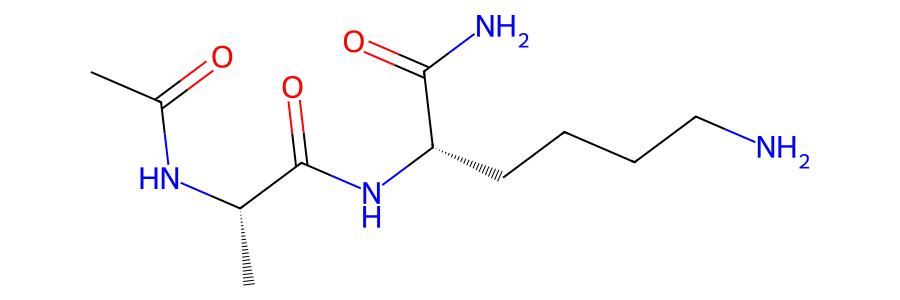

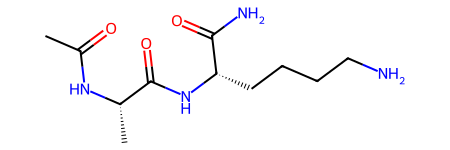

In [24]:
smiles = aa_seqs_to_smiles(
    "AK",
    n_terminal="MyNCap",
    c_terminal="MyCTail",
    n_terminal_overrides={"MyNCap": "CC(=O)O"},
    c_terminal_overrides={"MyCTail": "N"},
)
show_smiles(smiles)
        
